## Descenso del Gradiente

1. ¿Qué es el Descenso del Gradiente y para qué sirve?

El Descenso del Gradiente (Gradient Descent) es un algoritmo de optimización iterativo utilizado en Machine Learning para encontrar de forma automática los parámetros óptimos de un modelo (en Regresión Lineal, los valores de $w$ y $b$) que minimizan la Función de Costo $J(w,b)$.

Si la Función de Costo $J(w,b)$ es nuestra "brújula" para saber qué tan mal se equivoca el modelo, el Descenso del Gradiente es el motor que ajusta los parámetros paso a paso hasta llegar al menor error posible.

2. Intuición: ¿Cómo funciona?

Imagina que estás parado en la cima de una montaña o en el borde de un gran tazón (la superficie 3D de $J(w,b)$)::

Miras hacia abajo para sentir la pendiente del terreno bajo tus pies y das un paso pequeño en la dirección donde el terreno cae más empinado.

Repites este proceso: evalúas la pendiente, das otro paso y continúas descendiendo. Te detienes cuando el terreno a tu alrededor es totalmente plano (hemos llegado al mínimo global donde la pendiente es 0).

![Visualización del descenso del gradiente](./Resources/gradientDescent_visualization.png)

3. La Fórmula Matemáticamente Explicada

El algoritmo actualiza los parámetros $w$ y $b$ de forma simultánea en cada iteración mediante las siguientes ecuaciones:

$$w = w - \alpha \frac{\partial}{\partial w} J(w,b)$$

$$b = b - \alpha \frac{\partial}{\partial b} J(w,b)$$

Desglose de componentes:

- $w$ (o $b$): El valor actual del parámetro que queremos ajustar.
- $=$ (Asignación): Significa actualizar o reemplazar el valor anterior de $w$ con el nuevo valor calculado.
- $\alpha$ (Tasa de Aprendizaje / Learning Rate): Un número positivo pequeño (por ejemplo, $0.01$) que controla qué tan grande es el paso que damos en cada iteración. Si $\alpha$ es muy pequeño: El descenso será extremadamente lento. Si $\alpha$ es muy grande: Podemos "rebotar" o sobrepasar el punto mínimo y hacer que el algoritmo no converja.
- $\frac{\partial}{\partial w} J(w,b)$ (Derivada Parcial): Representa la pendiente (slope) de la función de costo en el punto actual con respecto a $w$.
- El signo menos ($- \alpha \dots$): Nos asegura que nos movamos en la dirección opuesta a la pendiente (si la pendiente sube hacia la derecha, nos movemos hacia la izquierda para bajar).

4. ¿Qué hace la Derivada Parcial en la Fórmula?

La derivada parcial indica la dirección y la inclinación de la pendiente en el punto exacto donde nos encontramos:

Si la pendiente es positiva ($\frac{\partial J}{\partial w} > 0$):
- La recta tangente sube hacia la derecha.
- La fórmula calcula: $w_{nuevo} = w_{actual} - \text{(número positivo)}$.
- Resultado: $w$ se reduce (se mueve hacia la izquierda) para descender la curva.

Si la pendiente es negativa ($\frac{\partial J}{\partial w} < 0$):
- La recta tangente cae hacia la derecha.
- La fórmula calcula: $w_{nuevo} = w_{actual} - \text{(número negativo)} = w_{actual} + \text{(número positivo)}$.
- Resultado: $w$ aumenta (se mueve hacia la derecha) para descender la curva.

Conforme te acercas al Mínimo Global:
- La pendiente se vuelve cada vez más llana o plana (la derivada parcial tiende a $0$).
- Como $\frac{\partial J}{\partial w} \approx 0$, el tamaño del paso $\alpha \cdot \frac{\partial J}{\partial w}$ se hace automáticamente cada vez más pequeño, permitiendo que el algoritmo se asiente suavemente en el punto más bajo.

![Visualización del trabajo de la derivada de la fórmula](./Resources/gradientDescent_derivative.png)

### Derivación Matemática de las Derivadas Parciales (OPCIONAL)

Partimos de la definición de la Función de Costo (Error Cuadrático Medio):

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

Donde $f_{w,b}(x^{(i)}) = w x^{(i)} + b$.

Para aplicar la regla de la cadena del cálculo multivariable, definimos el término interno del error como $u = f_{w,b}(x^{(i)}) - y^{(i)} = w x^{(i)} + b - y^{(i)}$.

1. Derivada Parcial con respecto a $w$

Queremos calcular:

$$\frac{\partial}{\partial w} J(w,b) = \frac{\partial}{\partial w} \left[ \frac{1}{2m} \sum_{i=1}^{m} \left( w x^{(i)} + b - y^{(i)} \right)^2 \right]$$

Paso 1: Sacar la constante fuera de la derivada

Como la derivada de una suma es la suma de las derivadas, pasamos la derivada dentro de la sumatoria:

$$= \frac{1}{2m} \sum_{i=1}^{m} \frac{\partial}{\partial w} \left( w x^{(i)} + b - y^{(i)} \right)^2$$

Paso 2: Aplicar la regla de la cadena $\frac{d}{dw}[u^2] = 2u \cdot \frac{du}{dw}$

El exponente $2$ pasa multiplicando al frente y le restamos $1$ al exponente:

$$= \frac{1}{2m} \sum_{i=1}^{m} 2 \cdot \left( w x^{(i)} + b - y^{(i)} \right)^{2-1} \cdot \frac{\partial}{\partial w} \left( w x^{(i)} + b - y^{(i)} \right)$$

Paso 3: Cancelar constantes y derivar el interior con respecto a $w$

El $2$ de la derivada se cancela exactamente con el $\frac{1}{2}$ de la constante $\frac{1}{2m}$ (para esto existía ese $\frac{1}{2}$ en la fórmula original).

Al derivar el interior $(w x^{(i)} + b - y^{(i)})$ con respecto a $w$:
- La derivada de $w x^{(i)}$ respecto a $w$ es $x^{(i)}$.
- La derivada de $b$ e $y^{(i)}$ respecto a $w$ es $0$ (se tratan como constantes).

$$= \frac{1}{m} \sum_{i=1}^{m} \left( w x^{(i)} + b - y^{(i)} \right) \cdot x^{(i)}$$

Resultado Final para $w$:

$$\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

2. Derivada Parcial con respecto a $b$

Repetimos el mismo procedimiento, pero derivando con respecto a $b$:

$$\frac{\partial}{\partial b} J(w,b) = \frac{\partial}{\partial b} \left[ \frac{1}{2m} \sum_{i=1}^{m} \left( w x^{(i)} + b - y^{(i)} \right)^2 \right]$$

Paso 1 y 2: Aplicar la regla de la cadena y cancelar el $2$

$$= \frac{1}{m} \sum_{i=1}^{m} \left( w x^{(i)} + b - y^{(i)} \right) \cdot \frac{\partial}{\partial b} \left( w x^{(i)} + b - y^{(i)} \right)$$

Paso 3: Derivar el interior con respecto a $b$Al derivar el interior $(w x^{(i)} + b - y^{(i)})$ con respecto a $b$:

- La derivada de $b$ respecto a $b$ es $1$.
- La derivada de $w x^{(i)}$ e $y^{(i)}$ respecto a $b$ es $0$.$$= \frac{1}{m} \sum_{i=1}^{m} \left( w x^{(i)} + b - y^{(i)} \right) \cdot 1$$

Resultado Final para $b$:

$$\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)$$

## Laboratorio Práctico: Descenso del Gradiente en Regresión Lineal

Objetivo

Programar las funciones compute_gradient y gradient_descent desde cero para entrenar automáticamente los parámetros $w$ y $b$, ajustando la recta de predicción a nuestro dataset de viviendas.

Paso 1: Importar Librerías y Definir Datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dataset de entrenamiento: TAMAÑO (x en m²) vs PRECIO (y en miles USD)
x_train = np.array([50.0, 70.0, 100.0, 120.0])
y_train = np.array([120.0, 160.0, 230.0, 280.0])

m = x_train.shape[0]

Paso 2: Función para Calcular las Derivadas Parciales (Gradiente)

Esta función calcula $\frac{\partial J}{\partial w}$ (dj_dw) y $\frac{\partial J}{\partial b}$ (dj_db) aplicando las derivadas resultantes que dedujimos:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)$$

In [2]:
def compute_gradient(x, y, w, b):
    """
    Calcula el gradiente (derivadas parciales) para la regresión lineal.
    """
    m = x.shape[0]
    dj_dw = 0.0
    dj_db = 0.0
    
    # Acumulamos el error en cada ejemplo i
    for i in range(m):
        f_wb = w * x[i] + b                # Predicción y_hat
        err_i = f_wb - y[i]                # Error (y_hat - y)
        
        dj_dw += err_i * x[i]              # Error * x^(i) para w
        dj_db += err_i                     # Error simple para b
        
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

Paso 3: Función de Descenso del Gradiente (Bucle de Entrenamiento)

Ejecuta el proceso iterativo actualizando $w$ y $b$ de forma simultánea en cada paso (epoch):

In [3]:
def compute_cost(x, y, w, b):
    """Calcula la función de costo J(w,b)"""
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i]) ** 2
    return cost / (2 * m)

def gradient_descent(x, y, w_in, b_in, alpha, num_iters):
    """
    Ejecuta el algoritmo de Descenso del Gradiente para encontrar w y b óptimos.
    """
    w = w_in
    b = b_in
    J_history = []  # Historial del costo para verificar convergencia
    
    for i in range(num_iters):
        # 1. Calcular las derivadas parciales actuales
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        
        # 2. Actualización SIMULTÁNEA de parámetros
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # 3. Guardar el costo en cada paso
        cost = compute_cost(x, y, w, b)
        J_history.append(cost)
        
        # Imprimir progreso cada 1,000 iteraciones
        if i % 1000 == 0 or i == num_iters - 1:
            print(f"Iteración {i:5d}: Costo J(w,b) = {cost:8.4f} | w = {w:6.4f}, b = {b:6.4f}")
            
    return w, b, J_history

Paso 4: Ejecutar el Entrenamiento

Inicializamos los parámetros en $0$, elegimos una tasa de aprendizaje $\alpha$ pequeña ($0.0001$) y corremos $10,000$ iteraciones.

In [7]:
# Parámetros iniciales
w_init = 0.0
b_init = 0.0

# Hiperparámetros
iterations = 10000
alpha = 0.0001

# Ejecutar Descenso del Gradiente
w_final, b_final, J_hist = gradient_descent(x_train, y_train, w_init, b_init, alpha, iterations)

print(f"\nValores óptimos encontrados:")
print(f"w final = {w_final:.4f}")
print(f"b final = {b_final:.4f}")

Iteración     0: Costo J(w,b) = 902.4462 | w = 1.8450, b = 0.0198
Iteración  1000: Costo J(w,b) =   3.5265 | w = 2.3202, b = 0.0481
Iteración  2000: Costo J(w,b) =   3.5212 | w = 2.3200, b = 0.0711
Iteración  3000: Costo J(w,b) =   3.5160 | w = 2.3198, b = 0.0940
Iteración  4000: Costo J(w,b) =   3.5109 | w = 2.3195, b = 0.1166
Iteración  5000: Costo J(w,b) =   3.5058 | w = 2.3193, b = 0.1390
Iteración  6000: Costo J(w,b) =   3.5009 | w = 2.3190, b = 0.1612
Iteración  7000: Costo J(w,b) =   3.4961 | w = 2.3188, b = 0.1832
Iteración  8000: Costo J(w,b) =   3.4913 | w = 2.3186, b = 0.2050
Iteración  9000: Costo J(w,b) =   3.4866 | w = 2.3183, b = 0.2266
Iteración  9999: Costo J(w,b) =   3.4820 | w = 2.3181, b = 0.2480

Valores óptimos encontrados:
w final = 2.3181
b final = 0.2480


Paso 5: Visualizar la Reducción del Costo $J(w,b)$

Graficamos cómo disminuye el costo con cada iteración. Una curva que desciende suavemente confirma que el algoritmo está convergiendo correctamente. También podremos observar como en los primeros pasos (iteraciones) el costo baja en picada pero a medida que avanzamos, va disminuyendo más lento cada vez, esto debido a que en cada iteración, nuestra derivada parcial se hace más y más pequeña debido a que la pendiente se va acercando a ser 0.

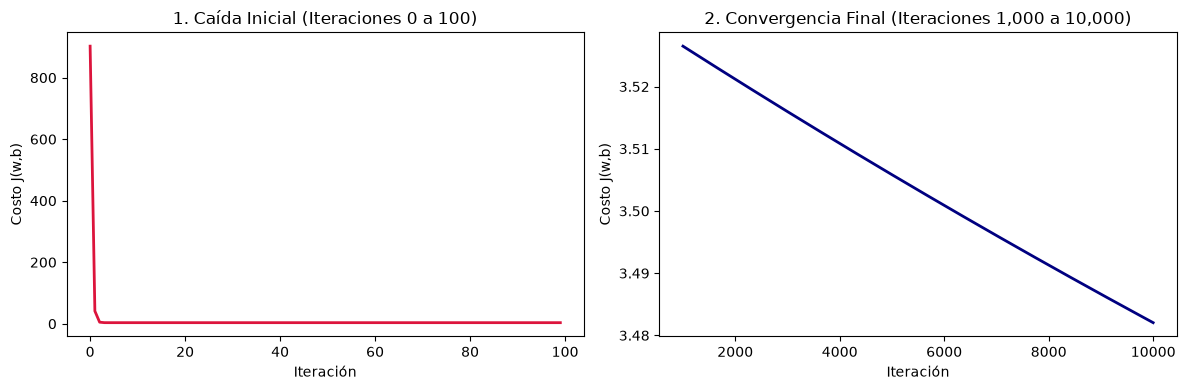

In [14]:
# Crear una figura con 2 gráficas independientes lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# -------------------------------------------------------------
# Gráfica 1: Primeros grandes pasos (Primeras 100 iteraciones)
# -------------------------------------------------------------
ax1.plot(J_hist[:100], c='crimson', linewidth=2)
ax1.set_title("1. Caída Inicial (Iteraciones 0 a 100)")
ax1.set_xlabel("Iteración")
ax1.set_ylabel("Costo J(w,b)")

# -------------------------------------------------------------
# Gráfica 2: Ajuste fino final (Últimas iteraciones)
# -------------------------------------------------------------
# Tomamos desde la iteración 1000 hasta el final
ax2.plot(range(1000, len(J_hist)), J_hist[1000:], c='navy', linewidth=2)
ax2.set_title("2. Convergencia Final (Iteraciones 1,000 a 10,000)")
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Costo J(w,b)")

plt.tight_layout()
plt.show()

Paso 6: Graficar la Recta de Ajuste Final

Comprobamos visualmente cómo la recta aprendida por el modelo atraviesa los datos de entrenamiento de manera óptima:

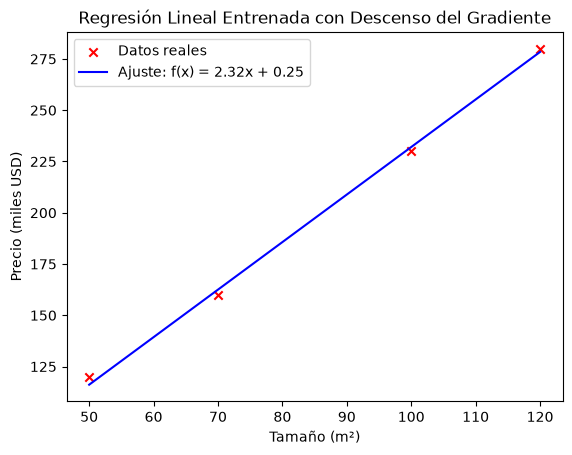

In [9]:
# Predicciones con los valores óptimos aprendidos
f_final = w_final * x_train + b_final

# Graficar datos y predicción
plt.scatter(x_train, y_train, marker='x', c='r', label='Datos reales')
plt.plot(x_train, f_final, c='b', label=f'Ajuste: f(x) = {w_final:.2f}x + {b_final:.2f}')
plt.title("Regresión Lineal Entrenada con Descenso del Gradiente")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (miles USD)")
plt.legend()
plt.show()

Paso 7: Hacer una Predicción para un Caso Nuevo

In [10]:
x_nuevo = 90.0  # Casa de 90 m²
precio_estimado = w_final * x_nuevo + b_final

print(f"Para una casa de {x_nuevo} m², el precio predicho es ${precio_estimado:.2f} mil USD.")

Para una casa de 90.0 m², el precio predicho es $208.88 mil USD.
